In [1]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [2]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import lightning as pl

from control.neuralsde import MLPSDE
from control.data import TimeSeriesDataset
from control.training import SDELightningModule, SDEWrapper
from control.contoller import StepController
from control.model import LinearControlSDE

In [ ]:
batch_size = 128
num_workers = 1
state_size = 2
control_size = 1
wlen_train = 10
hidden_size = 16
hidden_layers = 1
lr = 1e-3
method = "euler"
dt = 1e-2

In [4]:
train_set = np.load("data_processed/control/train.npz")
test_set = np.load("data_processed/control/test.npz")

train_dataset = TimeSeriesDataset(train_set, duplicate=100, window_length=wlen_train)
test_dataset = TimeSeriesDataset(test_set, window_length=200)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)    
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

In [5]:
ts = train_set["t"]

In [6]:
control_input = StepController()
base_model = MLPSDE(state_size, control_size, control_input=control_input, brownian_size=1, hidden_size=hidden_size, hidden_layers=hidden_layers, noise_type="diagonal")

In [7]:
lighting = SDELightningModule(base_model, lr, method, dt)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[
        pl.pytorch.callbacks.ModelCheckpoint(
            monitor='val_loss',
            dirpath='checkpoints/',
            filename='sde-{epoch:02d}-{val_loss:.4f}',
            save_top_k=3,
            mode='min'
        ),
        pl.pytorch.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            mode='min'
        )
    ],
    logger=pl.pytorch.loggers.WandbLogger(project='sde_training', name='sde_run', save_dir='logs/'),
    #gradient_clip_val=10.0,
    log_every_n_steps=10
)
    
# Train
trainer.fit(lighting, train_loader, val_loader)

# Test
#trainer.test(lighting, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


wandb: Currently logged in as: dani2442 (dani2442-fau) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/dani/projects/neuroscience/checkpoints exists and is not empty.

  | Name        | Type       | Params | Mode 
---------------------------------------------------
0 | sde_wrapper | SDEWrapper | 17.3 K | train
---------------------------------------------------
17.3 K    Trainable params
0         Non-trainable params
17.3 K    Total params
0.069     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 94/94 [00:05<00:00, 17.26it/s, v_num=lgao, train_loss=4.33e-6, lr=0.001, val_loss=0.00032]  

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 94/94 [00:05<00:00, 17.21it/s, v_num=lgao, train_loss=4.33e-6, lr=0.001, val_loss=0.00032]


In [8]:
x, u, ts = next(iter(train_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = lighting(x0, ts, u).transpose(1,0)

/tmp/ipykernel_64638/2805893479.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


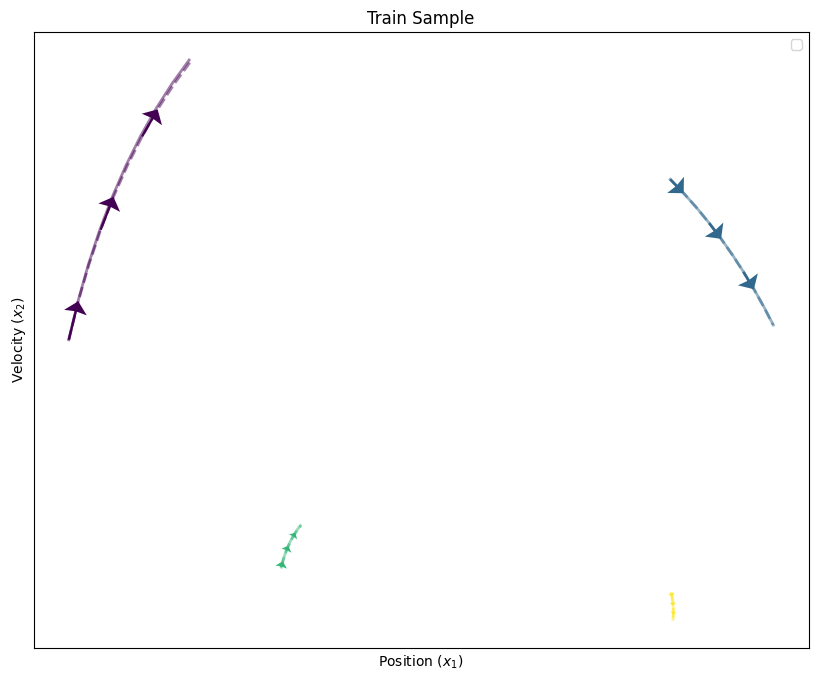

In [9]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--')
    plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Train Sample')
#plt.grid(True, alpha=0.3)
plt.xticks([]); plt.yticks([])
plt.legend(loc='upper right')
plt.savefig('images/phase_portrait_train.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
x, u, ts = next(iter(val_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = lighting(x0, ts,u).transpose(1,0)

/tmp/ipykernel_64638/3178916836.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


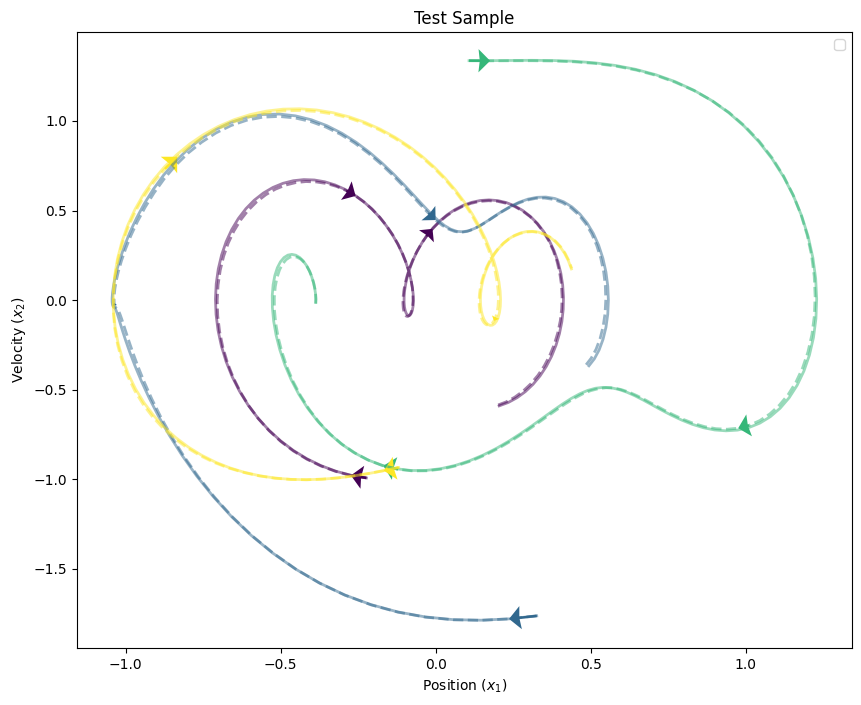

In [16]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--')
    plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Test Sample')
#plt.grid(True, alpha=0.3)
#plt.xticks([]); plt.yticks([])
plt.legend(loc='upper right')
plt.savefig('images/phase_portrait_train.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])
real_model = LinearControlSDE(A, B, control_input=control_input, sigma=0.0)
sde_wrapper_real = SDEWrapper(
    real_model,
    method=method,
    dt=0.01
)

In [13]:
x, u, ts = next(iter(val_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = sde_wrapper_real(x0, ts, u).transpose(1,0)

/tmp/ipykernel_64638/462963048.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


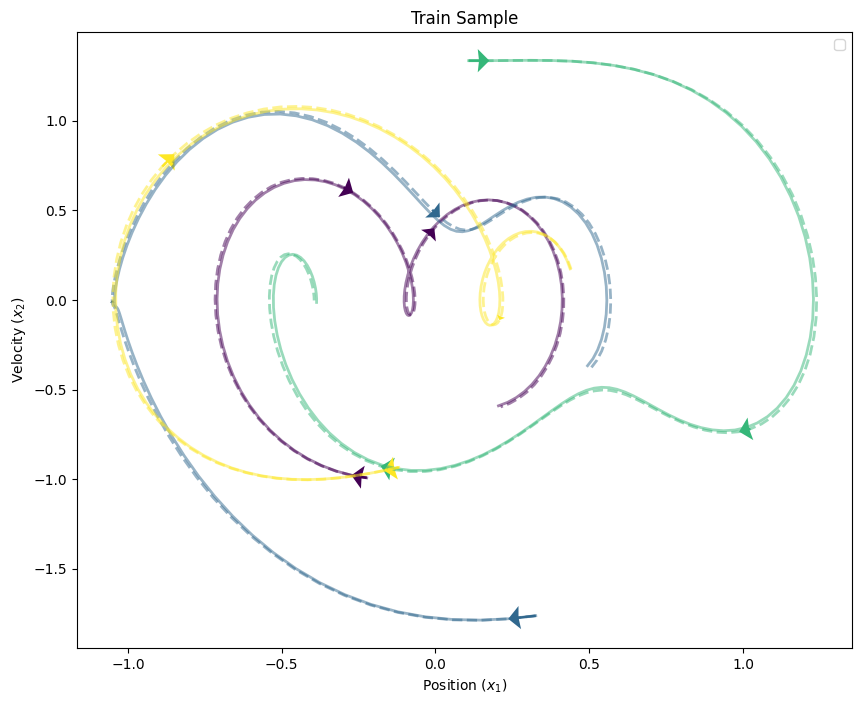

In [14]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--')
    plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Train Sample')
#plt.grid(True, alpha=0.3)
#plt.xticks([]); plt.yticks([])
plt.legend(loc='upper right')
plt.savefig('images/phase_portrait_train.png', dpi=300, bbox_inches='tight')
plt.show()